In [19]:
import pandas as pd
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

In [5]:
df = pd.read_csv("train.csv", usecols=["Age", "Fare", "Survived"])

In [6]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Age       714 non-null    float64
 2   Fare      891 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 21.0 KB


In [8]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [9]:
df["Age"].fillna(df["Age"].mean(), inplace=True)

In [10]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [11]:
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,1:], df.iloc[:,0], test_size=0.2, random_state=0)

In [12]:
X_train.head()

,Age,Fare
140,29.699118,15.2458
439,31.000000,10.5000
817,31.000000,37.0042
378,20.000000,4.0125
491,21.000000,7.2500


In [15]:
y_train.tail()

835    1
192    1
629    0
559    1
684    0
Name: Survived, dtype: int64

C:\Users\kumar\AppData\Local\Temp\ipykernel_10360\4243027187.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train["Age"])


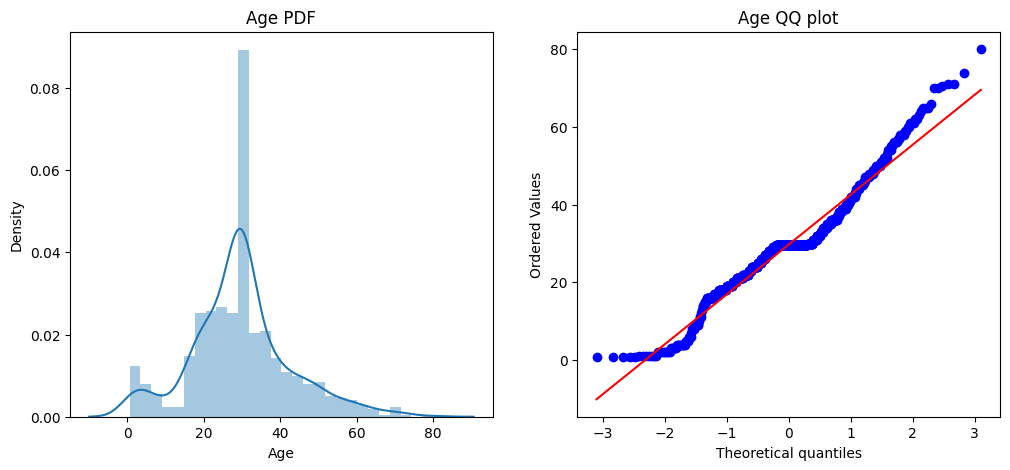

In [24]:
plt.figure(figsize=(12,5))
plt.subplot(121)
sns.distplot(X_train["Age"])
plt.title("Age PDF")

plt.subplot(122)
stats.probplot(X_train["Age"], dist = "norm", plot=plt)
plt.title("Age QQ plot")

plt.show()

C:\Users\kumar\AppData\Local\Temp\ipykernel_10360\3857648530.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train["Fare"])


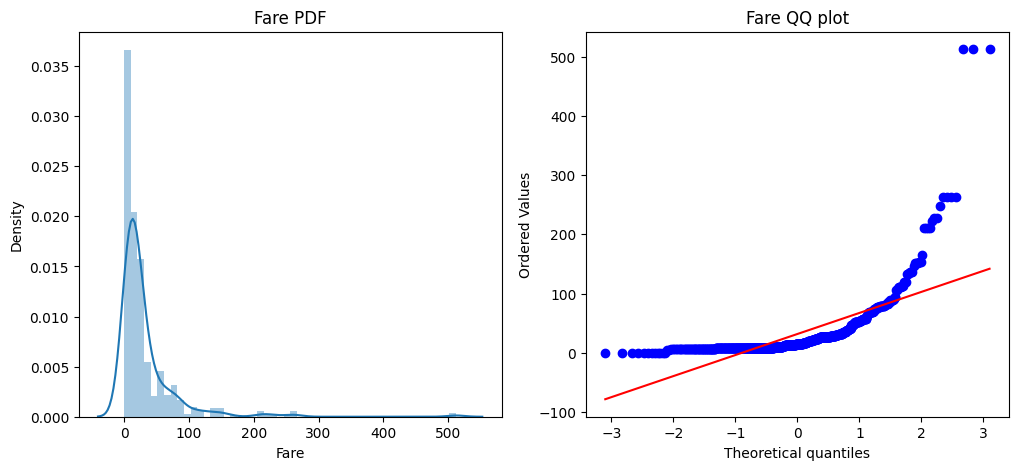

In [25]:
plt.figure(figsize=(12,5))
plt.subplot(121)
sns.distplot(X_train["Fare"])
plt.title("Fare PDF")

plt.subplot(122)
stats.probplot(X_train["Fare"], dist = "norm", plot=plt)
plt.title("Fare QQ plot")

plt.show()

# prediction without transform

In [39]:
clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [40]:
clf1.fit(X_train, y_train)
clf2.fit(X_train, y_train)

DecisionTreeClassifier()

In [41]:
y_pred = clf1.predict(X_test)
y_pred1 = clf2.predict(X_test)

In [42]:
print("Accuracy LR", accuracy_score(y_test, y_pred))
print("Accuracy DT", accuracy_score(y_test, y_pred1))

Accuracy LR 0.6983240223463687
Accuracy DT 0.6703910614525139


# prediction with log transform 

In [73]:
trf = FunctionTransformer(func=np.log1p)

In [74]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [88]:
clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf1.fit(X_train_transformed, y_train)
clf2.fit(X_train_transformed, y_train)

y_pred = clf1.predict(X_test_transformed)
y_pred1 = clf2.predict(X_test_transformed)

print("Accuracy LR", accuracy_score(y_test, y_pred))
print("Accuracy DT", accuracy_score(y_test, y_pred1))

Accuracy LR 0.7039106145251397
Accuracy DT 0.659217877094972


In [89]:
X_transformed = trf.fit_transform(df.iloc[:,1:])

clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("lr", np.mean(cross_val_score(clf1, X_transformed, df.iloc[:,0], scoring="accuracy", cv=10)))
print("dt", np.mean(cross_val_score(clf2, X_transformed, df.iloc[:,0], scoring="accuracy", cv=10)))

lr 0.678027465667915
dt 0.6577278401997504


C:\Users\kumar\AppData\Local\Temp\ipykernel_10360\3112314666.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train["Age"])
C:\Users\kumar\AppData\Local\Temp\ipykernel_10360\3112314666.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_transformed["Age"])


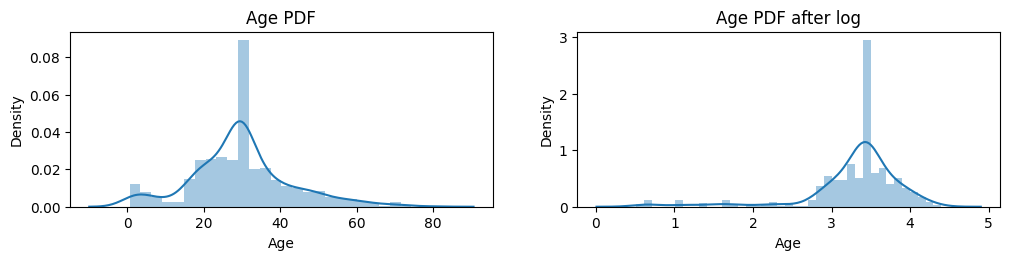

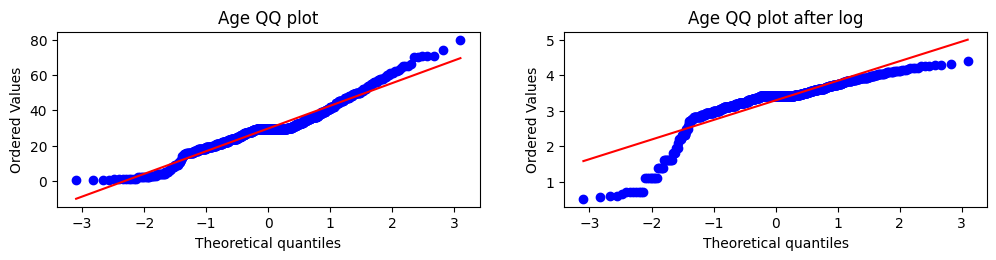

In [90]:
plt.figure(figsize=(12,5))
plt.subplot(221)
sns.distplot(X_train["Age"])
plt.title("Age PDF")

#plt.figure(figsize=(12,5))
plt.subplot(222)
sns.distplot(X_train_transformed["Age"])
plt.title("Age PDF after log")

plt.figure(figsize=(12,5))
plt.subplot(223)
stats.probplot(X_train["Age"], dist = "norm", plot=plt)
plt.title("Age QQ plot")

#plt.figure(figsize=(12,5))
plt.subplot(224)
stats.probplot(X_train_transformed["Age"], dist = "norm", plot=plt)
plt.title("Age QQ plot after log")

plt.show()

C:\Users\kumar\AppData\Local\Temp\ipykernel_10360\633745037.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train["Fare"])
C:\Users\kumar\AppData\Local\Temp\ipykernel_10360\633745037.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_transformed["Fare"])


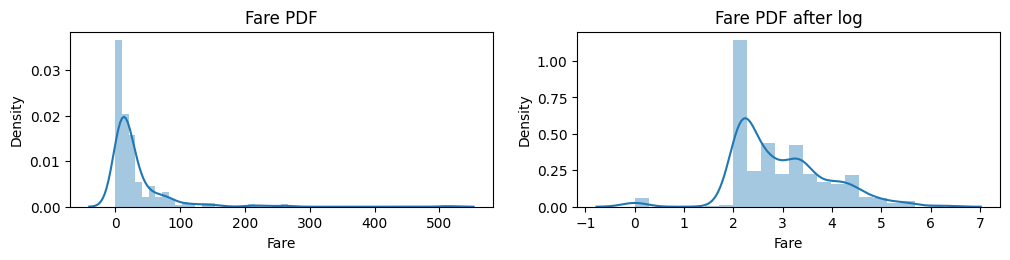

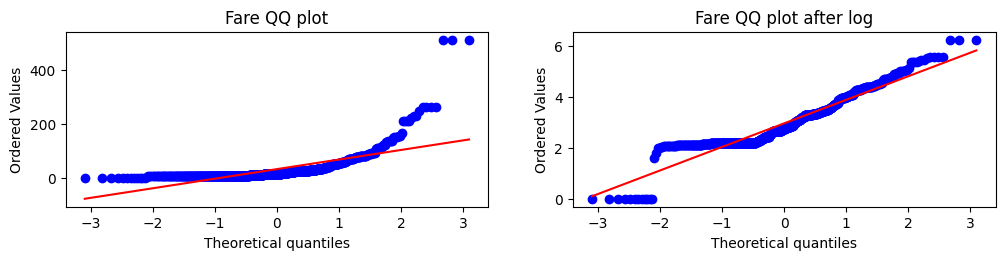

In [91]:
plt.figure(figsize=(12,5))
plt.subplot(221)
sns.distplot(X_train["Fare"])
plt.title("Fare PDF")

#plt.figure(figsize=(12,5))
plt.subplot(222)
sns.distplot(X_train_transformed["Fare"])
plt.title("Fare PDF after log")

plt.figure(figsize=(12,5))
plt.subplot(223)
stats.probplot(X_train["Fare"], dist = "norm", plot=plt)
plt.title("Fare QQ plot")

#plt.figure(figsize=(12,5))
plt.subplot(224)
stats.probplot(X_train_transformed["Fare"], dist = "norm", plot=plt)
plt.title("Fare QQ plot after log")

plt.show()

# In fare we can see the improvemnet after log transform

# applying log transform only on fare column

In [92]:
trf2 = ColumnTransformer([("tnf", FunctionTransformer(np.log1p,validate=False), ["Fare"])], remainder="passthrough")

In [93]:
X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test)

In [94]:
clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf1.fit(X_train_transformed2, y_train)
clf2.fit(X_train_transformed2, y_train)

y_pred = clf1.predict(X_test_transformed2)
y_pred1 = clf2.predict(X_test_transformed2)

print("Accuracy LR", accuracy_score(y_test, y_pred))
print("Accuracy DT", accuracy_score(y_test, y_pred1))

Accuracy LR 0.6815642458100558
Accuracy DT 0.6703910614525139


In [95]:
X_transformed2 = trf2.fit_transform(df.iloc[:,1:])

clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("lr", np.mean(cross_val_score(clf1, X_transformed2, df.iloc[:,0], scoring="accuracy", cv=10)))
print("dt", np.mean(cross_val_score(clf2, X_transformed2, df.iloc[:,0], scoring="accuracy", cv=10)))

lr 0.6712609238451936
dt 0.6689138576779026


In [96]:
def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]
    
    trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')
    
    X_trans = trf.fit_transform(X)
    
    clf = LogisticRegression()
    
    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))
    
    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()

Accuracy 0.6431335830212235


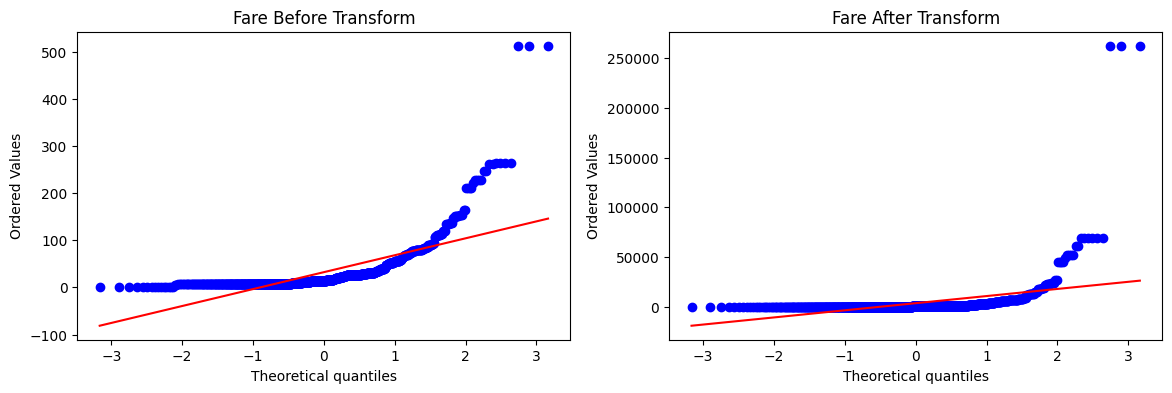

In [112]:
apply_transform(lambda x: x**2)